In [1]:
from google.colab import files
files.upload()

Saving kaggle.json to kaggle (3).json


{'kaggle (3).json': b'{"username":"makuro041","key":"ba4363a0496312bb208d843c210f8440"}'}

In [2]:
!mkdir -p ~/.kaggle
!cp kaggle.json ~/.kaggle/
!chmod 600 ~/.kaggle/kaggle.json

In [3]:
!kaggle datasets download -d mlg-ulb/creditcardfraud --unzip -p data/

Dataset URL: https://www.kaggle.com/datasets/mlg-ulb/creditcardfraud
License(s): DbCL-1.0
100% 66.0M/66.0M [00:04<00:00, 16.2MB/s]



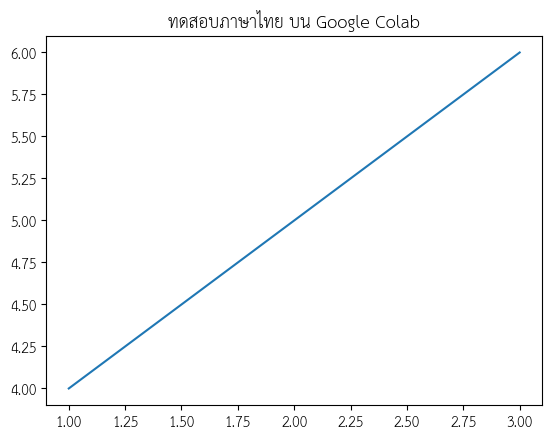

In [4]:
!wget -q https://github.com/Phonbopit/sarabun-webfont/raw/master/fonts/thsarabunnew-webfont.ttf

import matplotlib as mpl
import matplotlib.pyplot as plt

mpl.font_manager.fontManager.addfont('thsarabunnew-webfont.ttf')

mpl.rc('font', family='TH Sarabun New')

plt.title("ทดสอบภาษาไทย บน Google Colab")
plt.plot([1, 2, 3], [4, 5, 6])
plt.show()

In [5]:
import pandas as pd
import matplotlib.pyplot as plt
import seaborn as sns
df = pd.read_csv("data/creditcard.csv")
df.shape
df.describe()

,Time,V1,V2,V3,V4,V5,V6,V7,V8,V9,...,V21,V22,V23,V24,V25,V26,V27,V28,Amount,Class
count,284807.000000,2.848070e+05,2.848070e+05,2.848070e+05,2.848070e+05,2.848070e+05,2.848070e+05,2.848070e+05,2.848070e+05,2.848070e+05,...,2.848070e+05,2.848070e+05,2.848070e+05,2.848070e+05,2.848070e+05,2.848070e+05,2.848070e+05,2.848070e+05,284807.000000,284807.000000
mean,94813.859575,1.168375e-15,3.416908e-16,-1.379537e-15,2.074095e-15,9.604066e-16,1.487313e-15,-5.556467e-16,1.213481e-16,-2.406331e-15,...,1.654067e-16,-3.568593e-16,2.578648e-16,4.473266e-15,5.340915e-16,1.683437e-15,-3.660091e-16,-1.227390e-16,88.349619,0.001727
std,47488.145955,1.958696e+00,1.651309e+00,1.516255e+00,1.415869e+00,1.380247e+00,1.332271e+00,1.237094e+00,1.194353e+00,1.098632e+00,...,7.345240e-01,7.257016e-01,6.244603e-01,6.056471e-01,5.212781e-01,4.822270e-01,4.036325e-01,3.300833e-01,250.120109,0.041527
min,0.000000,-5.640751e+01,-7.271573e+01,-4.832559e+01,-5.683171e+00,-1.137433e+02,-2.616051e+01,-4.355724e+01,-7.321672e+01,-1.343407e+01,...,-3.483038e+01,-1.093314e+01,-4.480774e+01,-2.836627e+00,-1.029540e+01,-2.604551e+00,-2.256568e+01,-1.543008e+01,0.000000,0.000000
25%,54201.500000,-9.203734e-01,-5.985499e-01,-8.903648e-01,-8.486401e-01,-6.915971e-01,-7.682956e-01,-5.540759e-01,-2.086297e-01,-6.430976e-01,...,-2.283949e-01,-5.423504e-01,-1.618463e-01,-3.545861e-01,-3.171451e-01,-3.269839e-01,-7.083953e-02,-5.295979e-02,5.600000,0.000000
50%,84692.000000,1.810880e-02,6.548556e-02,1.798463e-01,-1.984653e-02,-5.433583e-02,-2.741871e-01,4.010308e-02,2.235804e-02,-5.142873e-02,...,-2.945017e-02,6.781943e-03,-1.119293e-02,4.097606e-02,1.659350e-02,-5.213911e-02,1.342146e-03,1.124383e-02,22.000000,0.000000
75%,139320.500000,1.315642e+00,8.037239e-01,1.027196e+00,7.433413e-01,6.119264e-01,3.985649e-01,5.704361e-01,3.273459e-01,5.971390e-01,...,1.863772e-01,5.285536e-01,1.476421e-01,4.395266e-01,3.507156e-01,2.409522e-01,9.104512e-02,7.827995e-02,77.165000,0.000000
max,172792.000000,2.454930e+00,2.205773e+01,9.382558e+00,1.687534e+01,3.480167e+01,7.330163e+01,1.205895e+02,2.000721e+01,1.559499e+01,...,2.720284e+01,1.050309e+01,2.252841e+01,4.584549e+00,7.519589e+00,3.517346e+00,3.161220e+01,3.384781e+01,25691.160000,1.000000


In [6]:
import pandas as pd

features = ["Time", "Amount"] + [f"V{i}" for i in range(1, 29)]

X_raw = df[features]
y = df["Class"]

print("ค่าหายในฟีเจอร์:", X_raw.isnull().sum().sum())
print("สัดส่วนคลาสฉ้อโกง (Fraud):", round(y.mean(), 5))

ค่าหายในฟีเจอร์: 0
สัดส่วนคลาสฉ้อโกง (Fraud): 0.00173


In [7]:
import pandas as pd
from sklearn.preprocessing import MinMaxScaler

scaler = MinMaxScaler()

X = pd.DataFrame(scaler.fit_transform(X_raw), columns=X_raw.columns)

print("ช่วงค่าหลังสเกล - min:", X.values.min(), "max:", X.values.max())

ช่วงค่าหลังสเกล - min: 0.0 max: 1.0


In [8]:
from sklearn.model_selection import train_test_split

X_train, X_test, y_train, y_test = train_test_split(
    X, y, test_size=0.2, random_state=42, stratify=y
)

print("ขนาด X_train:", X_train.shape)
print("ขนาด X_test :", X_test.shape)

print("จำนวน Fraud ใน Train:", y_train.sum())
print("จำนวน Fraud ใน Test  :", y_test.sum())

ขนาด X_train: (227845, 30)
ขนาด X_test : (56962, 30)
จำนวน Fraud ใน Train: 394
จำนวน Fraud ใน Test  : 98


In [9]:
print("X_train min:", X_train.values.min(), "| max:", X_train.values.max())
print("X_test  min:", X_test.values.min(),  "| max:", X_test.values.max())

print("\n" + "="*40 + "\n")

print("สัดส่วน Fraud ใน train :", round(y_train.mean(), 5))
print("สัดส่วน Fraud ใน test  :", round(y_test.mean(), 5))
print("สัดส่วน Fraud ใน ทั้งหมด:", round(y.mean(), 5))

X_train min: 0.0 | max: 1.0
X_test  min: 0.0 | max: 1.0


สัดส่วน Fraud ใน train : 0.00173
สัดส่วน Fraud ใน test  : 0.00172
สัดส่วน Fraud ใน ทั้งหมด: 0.00173


In [10]:
import tensorflow as plt
from tensorflow.keras.layers import Dense, Input
from tensorflow.keras.models import Sequential

model = Sequential([
    Input(shape=(X_train.shape[1],)),

    Dense(8, activation="relu"),
    Dense(4, activation="relu"),

    Dense(1, activation="sigmoid")
])

model.summary()

Model: "sequential"

┏━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━┓
┃ Layer (type)                    ┃ Output Shape           ┃       Param # ┃
┡━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━┩
│ dense (Dense)                   │ (None, 8)              │           248 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dense_1 (Dense)                 │ (None, 4)              │            36 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dense_2 (Dense)                 │ (None, 1)              │             5 │
└─────────────────────────────────┴────────────────────────┴───────────────┘

 Total params: 289 (1.13 KB)

 Trainable params: 289 (1.13 KB)

 Non-trainable params: 0 (0.00 B)

In [11]:
import tensorflow as tf
from tensorflow.keras.metrics import AUC, Precision, Recall

model.compile(
    optimizer="adam",
    loss="binary_crossentropy",
    metrics=[
        "accuracy",
        Precision(name="precision"),
        Recall(name="recall"),
        AUC(name="auc")
    ]
)

print("คอมไพล์โมเดลเรียบร้อย พร้อมสำหรับขั้นตอนการ Fit/Train ครับ!")

คอมไพล์โมเดลเรียบร้อย พร้อมสำหรับขั้นตอนการ Fit/Train ครับ!


In [12]:
model.summary()

Model: "sequential"

┏━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━┓
┃ Layer (type)                    ┃ Output Shape           ┃       Param # ┃
┡━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━┩
│ dense (Dense)                   │ (None, 8)              │           248 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dense_1 (Dense)                 │ (None, 4)              │            36 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dense_2 (Dense)                 │ (None, 1)              │             5 │
└─────────────────────────────────┴────────────────────────┴───────────────┘

 Total params: 289 (1.13 KB)

 Trainable params: 289 (1.13 KB)

 Non-trainable params: 0 (0.00 B)

In [13]:
history = model.fit(
    X_train,
    y_train,
    epochs=20,
    batch_size=2048,
    validation_data=(X_test, y_test),
    verbose=1
)

Epoch 1/20
112/112 ━━━━━━━━━━━━━━━━━━━━ 2s 5ms/step - accuracy: 0.8084 - auc: 0.5219 - loss: 0.6727 - precision: 0.0014 - recall: 0.1523 - val_accuracy: 0.9983 - val_auc: 0.4994 - val_loss: 0.6399 - val_precision: 0.0000e+00 - val_recall: 0.0000e+00
Epoch 2/20
112/112 ━━━━━━━━━━━━━━━━━━━━ 0s 2ms/step - accuracy: 0.9983 - auc: 0.4835 - loss: 0.6153 - precision: 0.0000e+00 - recall: 0.0000e+00 - val_accuracy: 0.9983 - val_auc: 0.5039 - val_loss: 0.5907 - val_precision: 0.0000e+00 - val_recall: 0.0000e+00
Epoch 3/20
112/112 ━━━━━━━━━━━━━━━━━━━━ 0s 3ms/step - accuracy: 0.9983 - auc: 0.5255 - loss: 0.5681 - precision: 0.0000e+00 - recall: 0.0000e+00 - val_accuracy: 0.9983 - val_auc: 0.4997 - val_loss: 0.5456 - val_precision: 0.0000e+00 - val_recall: 0.0000e+00
Epoch 4/20
112/112 ━━━━━━━━━━━━━━━━━━━━ 0s 3ms/step - accuracy: 0.9983 - auc: 0.4994 - loss: 0.5250 - precision: 0.0000e+00 - recall: 0.0000e+00 - val_accuracy: 0.9983 - val_auc: 0.5048 - val_loss: 0.5043 - val_precision: 0.0000e+00 -

In [14]:
eval_results = model.evaluate(X_test, y_test, verbose=0)

test_loss = eval_results[0]
test_acc = eval_results[1]
test_prec = eval_results[2] if len(eval_results) > 2 else None
test_rec = eval_results[3] if len(eval_results) > 3 else None

print("=== ผลการประเมิน Neural Network บน Test Set ===")
print(f"NN test loss     : {test_loss:.4f}")
print(f"NN test accuracy : {test_acc:.6f}")

if test_prec is not None and test_rec is not None:
    print(f"NN test precision: {test_prec:.4f}")
    print(f"NN test recall   : {test_rec:.4f}")

=== ผลการประเมิน Neural Network บน Test Set ===
NN test loss     : 0.1658
NN test accuracy : 0.998280
NN test precision: 0.0000
NN test recall   : 0.0000


In [15]:
eval_train = model.evaluate(X_train, y_train, verbose=0)
eval_test = model.evaluate(X_test, y_test, verbose=0)

train_acc, test_acc = eval_train[1], eval_test[1]

print("=== เปรียบเทียบ Accuracy ===")
print("train accuracy :", round(train_acc, 6))
print("test accuracy  :", round(test_acc, 6))
print("diff (train-test):", round(train_acc - test_acc, 6))

if len(eval_train) > 3:
    train_rec, test_rec = eval_train[3], eval_test[3]
    print("\n" + "="*30 + "\n")
    print("=== เปรียบเทียบ Recall (อัตราจับ Fraud) ===")
    print("train recall   :", round(train_rec, 4))
    print("test recall    :", round(test_rec, 4))

=== เปรียบเทียบ Accuracy ===
train accuracy : 0.998271
test accuracy  : 0.99828
diff (train-test): -9e-06


=== เปรียบเทียบ Recall (อัตราจับ Fraud) ===
train recall   : 0.0
test recall    : 0.0


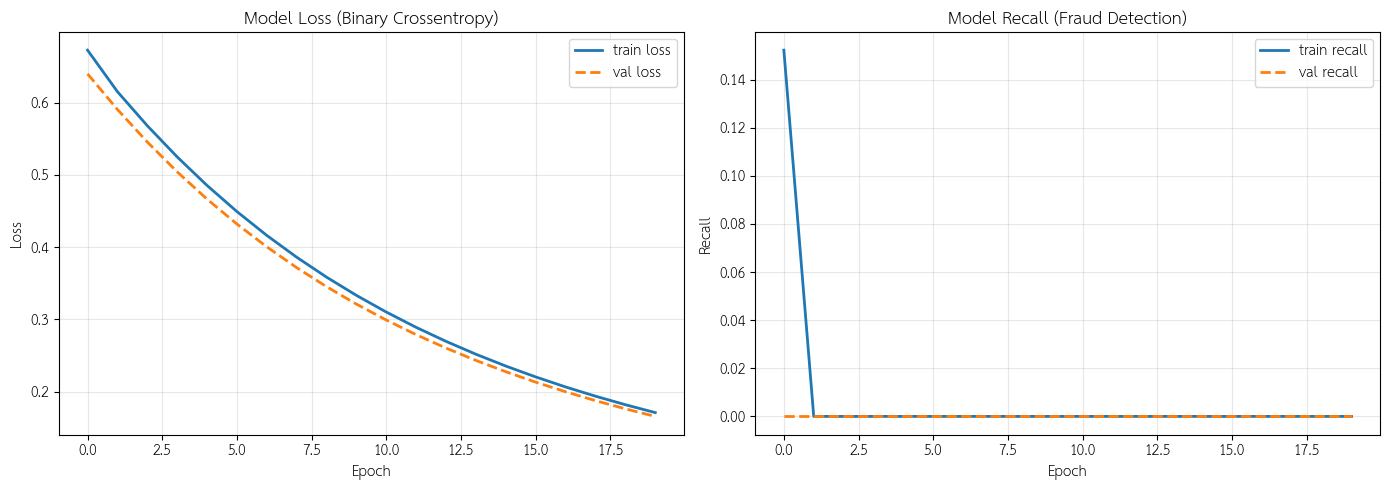

In [16]:
import matplotlib.pyplot as plt

fig, (ax1, ax2) = plt.subplots(1, 2, figsize=(14, 5))

ax1.plot(history.history["loss"], label="train loss", linewidth=2)
ax1.plot(history.history["val_loss"], label="val loss", linewidth=2, linestyle="--")
ax1.set_title("Model Loss (Binary Crossentropy)", fontsize=12)
ax1.set_xlabel("Epoch")
ax1.set_ylabel("Loss")
ax1.legend()
ax1.grid(True, alpha=0.3)

if "recall" in history.history:
    ax2.plot(history.history["recall"], label="train recall", linewidth=2)
    ax2.plot(history.history["val_recall"], label="val recall", linewidth=2, linestyle="--")
    ax2.set_title("Model Recall (Fraud Detection)", fontsize=12)
    ax2.set_xlabel("Epoch")
    ax2.set_ylabel("Recall")
    ax2.legend()
    ax2.grid(True, alpha=0.3)

plt.tight_layout()
plt.show()

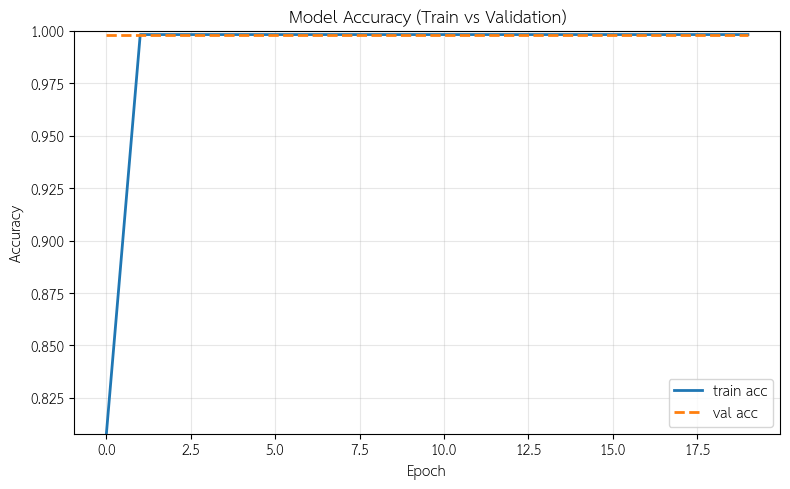

In [17]:
import matplotlib.pyplot as plt

plt.figure(figsize=(8, 5))
plt.plot(history.history["accuracy"], label="train acc", linewidth=2)
plt.plot(history.history["val_accuracy"], label="val acc", linewidth=2, linestyle="--")

plt.title("Model Accuracy (Train vs Validation)", fontsize=12)
plt.xlabel("Epoch")
plt.ylabel("Accuracy")
plt.legend(loc="lower right")
plt.grid(True, alpha=0.3)

min_acc = min(min(history.history["accuracy"]), min(history.history["val_accuracy"]))
plt.ylim(min_acc - 0.0005, 1.0001)

plt.tight_layout()
plt.show()

In [18]:
import pandas as pd

proba = model.predict(X_test[:5])

y_true_sample = y_test.iloc[:5].reset_index(drop=True)

print("=== แสดงผลการทำนาย 5 ตัวอย่างแรก ===")
for i, p in enumerate(proba):
    prob_val = float(p[0])
    pred_class = int(prob_val > 0.5)
    actual_class = y_true_sample.iloc[i]

    print(f"ตัวอย่างที่ {i+1} | Prob Fraud: {prob_val:.4f} -> ทำนาย: {pred_class} | จริง: {actual_class}")

1/1 ━━━━━━━━━━━━━━━━━━━━ 0s 49ms/step
=== แสดงผลการทำนาย 5 ตัวอย่างแรก ===
ตัวอย่างที่ 1 | Prob Fraud: 0.1503 -> ทำนาย: 0 | จริง: 0
ตัวอย่างที่ 2 | Prob Fraud: 0.1503 -> ทำนาย: 0 | จริง: 0
ตัวอย่างที่ 3 | Prob Fraud: 0.1503 -> ทำนาย: 0 | จริง: 0
ตัวอย่างที่ 4 | Prob Fraud: 0.1503 -> ทำนาย: 0 | จริง: 0
ตัวอย่างที่ 5 | Prob Fraud: 0.1503 -> ทำนาย: 0 | จริง: 0


In [19]:
import numpy as np
from sklearn.metrics import classification_report, confusion_matrix

pred_proba = model.predict(X_test)
pred = (pred_proba > 0.5).astype("int32")

print("=== Confusion Matrix ===")
cm = confusion_matrix(y_test, pred)
print(cm)

print("\n" + "="*50 + "\n")

print("=== Classification Report ===")
print(
    classification_report(
        y_test, pred, target_names=["ปกติ (Normal)", "ฉ้อโกง (Fraud)"], digits=4
    )
)

1781/1781 ━━━━━━━━━━━━━━━━━━━━ 1s 732us/step
=== Confusion Matrix ===
[[56864     0]
 [   98     0]]


=== Classification Report ===
                precision    recall  f1-score   support

 ปกติ (Normal)     0.9983    1.0000    0.9991     56864
ฉ้อโกง (Fraud)     0.0000    0.0000    0.0000        98

      accuracy                         0.9983     56962
     macro avg     0.4991    0.5000    0.4996     56962
  weighted avg     0.9966    0.9983    0.9974     56962



/usr/local/lib/python3.13/dist-packages/sklearn/metrics/_classification.py:1565: UndefinedMetricWarning: Precision is ill-defined and being set to 0.0 in labels with no predicted samples. Use `zero_division` parameter to control this behavior.
  _warn_prf(average, modifier, f"{metric.capitalize()} is", len(result))
/usr/local/lib/python3.13/dist-packages/sklearn/metrics/_classification.py:1565: UndefinedMetricWarning: Precision is ill-defined and being set to 0.0 in labels with no predicted samples. Use `zero_division` parameter to control this behavior.
  _warn_prf(average, modifier, f"{metric.capitalize()} is", len(result))
/usr/local/lib/python3.13/dist-packages/sklearn/metrics/_classification.py:1565: UndefinedMetricWarning: Precision is ill-defined and being set to 0.0 in labels with no predicted samples. Use `zero_division` parameter to control this behavior.
  _warn_prf(average, modifier, f"{metric.capitalize()} is", len(result))


In [20]:
import tensorflow as tf
from tensorflow.keras.layers import Dense, Input
from tensorflow.keras.models import Sequential

model_big = Sequential([
    Input(shape=(X_train.shape[1],)),
    Dense(16, activation="relu"),
    Dense(8, activation="relu"),
    Dense(1, activation="sigmoid")
])

model_big.compile(
    optimizer="adam",
    loss="binary_crossentropy",
    metrics=["accuracy", tf.keras.metrics.Recall(name="recall")]
)

history_big = model_big.fit(
    X_train, y_train,
    epochs=20,
    batch_size=2048,
    validation_data=(X_test, y_test),
    verbose=1
)

eval_base = model.evaluate(X_test, y_test, verbose=0)
eval_big = model_big.evaluate(X_test, y_test, verbose=0)

print("\n" + "="*50)
print("=== ผลการเปรียบเทียบประสิทธิภาพบน Test Set ===")
print(f"Accuracy (เดิม 8-4-1)  : {eval_base[1]:.6f}")
print(f"Accuracy (ใหญ่ 16-8-1) : {eval_big[1]:.6f}")
print("-" * 50)
print(f"Recall   (เดิม 8-4-1)  : {eval_base[2]:.4f}")
print(f"Recall   (ใหญ่ 16-8-1) : {eval_big[2]:.4f}")
print("="*50)

Epoch 1/20
112/112 ━━━━━━━━━━━━━━━━━━━━ 1s 4ms/step - accuracy: 0.9983 - loss: 0.0543 - recall: 0.0000e+00 - val_accuracy: 0.9983 - val_loss: 0.0131 - val_recall: 0.0000e+00
Epoch 2/20
112/112 ━━━━━━━━━━━━━━━━━━━━ 0s 2ms/step - accuracy: 0.9983 - loss: 0.0123 - recall: 0.0000e+00 - val_accuracy: 0.9983 - val_loss: 0.0117 - val_recall: 0.0000e+00
Epoch 3/20
112/112 ━━━━━━━━━━━━━━━━━━━━ 0s 2ms/step - accuracy: 0.9983 - loss: 0.0115 - recall: 0.0000e+00 - val_accuracy: 0.9983 - val_loss: 0.0110 - val_recall: 0.0000e+00
Epoch 4/20
112/112 ━━━━━━━━━━━━━━━━━━━━ 0s 2ms/step - accuracy: 0.9983 - loss: 0.0107 - recall: 0.0000e+00 - val_accuracy: 0.9983 - val_loss: 0.0101 - val_recall: 0.0000e+00
Epoch 5/20
112/112 ━━━━━━━━━━━━━━━━━━━━ 0s 2ms/step - accuracy: 0.9983 - loss: 0.0097 - recall: 0.0000e+00 - val_accuracy: 0.9983 - val_loss: 0.0089 - val_recall: 0.0000e+00
Epoch 6/20
112/112 ━━━━━━━━━━━━━━━━━━━━ 0s 2ms/step - accuracy: 0.9983 - loss: 0.0086 - recall: 0.0000e+00 - val_accuracy: 0.9983 

In [21]:
import tensorflow as tf
from tensorflow.keras.layers import Dense, Input
from tensorflow.keras.models import Sequential

for ep in [20, 50, 100]:
    m = Sequential([
        Input(shape=(X_train.shape[1],)),
        Dense(8, activation="relu"),
        Dense(4, activation="relu"),
        Dense(1, activation="sigmoid")
    ])

    m.compile(
        optimizer="adam",
        loss="binary_crossentropy",
        metrics=["accuracy", tf.keras.metrics.Recall(name="recall")]
    )

    m.fit(X_train, y_train, epochs=ep, batch_size=2048, verbose=0)

    results = m.evaluate(X_test, y_test, verbose=0)
    test_acc = results[1]
    test_rec = results[2]

    print(f"epochs: {ep:3d} -> Test Accuracy: {test_acc:.6f} | Test Recall: {test_rec:.4f}")

epochs:  20 -> Test Accuracy: 0.999017 | Test Recall: 0.5612
epochs:  50 -> Test Accuracy: 0.998280 | Test Recall: 0.0000
epochs: 100 -> Test Accuracy: 0.999280 | Test Recall: 0.8061


In [22]:
import pandas as pd

results = [
    {
        "Model": "Decision Tree (wk5)",
        "Accuracy": 0.9992,
        "Recall": 0.7500
    },
    {
        "Model": "Neural Network (wk6)",
        "Accuracy": round(float(test_acc), 6),
        "Recall": round(float(test_rec), 4) if 'test_rec' in globals() else "N/A"
    }
]

df_comparison = pd.DataFrame(results)

print("=== สรุปผลการเปรียบเทียบโมเดล ===")
df_comparison

=== สรุปผลการเปรียบเทียบโมเดล ===


,Model,Accuracy,Recall
0,Decision Tree (wk5),0.99920,0.7500
1,Neural Network (wk6),0.99928,0.8061


In [23]:
# ติดตั้ง imbalanced-learn หากยังไม่มีใน Colab
!pip install -q imbalanced-learn

import pandas as pd
from sklearn.model_selection import train_test_split
from sklearn.preprocessing import StandardScaler
from sklearn.ensemble import RandomForestClassifier
from sklearn.metrics import classification_report, confusion_matrix
from imblearn.over_sampling import SMOTE

In [24]:
# แยก Features และ Target
X = df.drop(columns=['Class'])
y = df['Class']

# แบ่งข้อมูลเป็น Train และ Test (ต้องทำก่อน SMOTE เสมอ เพื่อป้องกัน Data Leakage)
X_train, X_test, y_train, y_test = train_test_split(
    X, y, test_size=0.2, random_state=42, stratify=y
)

# Scaling ข้อมูล (เน้น Scale ตัวแปร Time และ Amount)
scaler = StandardScaler()
X_train_scaled = scaler.fit_transform(X_train)
X_test_scaled = scaler.transform(X_test)

In [25]:
# ตัวอย่างการใช้กับ Random Forest
model_cw = RandomForestClassifier(
    class_weight='balanced', # คำนวณน้ำหนักให้อัตโนมัติ
    random_state=42,
    n_jobs=-1
)

model_cw.fit(X_train_scaled, y_train)
y_pred_cw = model_cw.predict(X_test_scaled)

print("--- Class Weights Results ---")
print(classification_report(y_test, y_pred_cw))

--- Class Weights Results ---
              precision    recall  f1-score   support

           0       1.00      1.00      1.00     56864
           1       0.96      0.74      0.84        98

    accuracy                           1.00     56962
   macro avg       0.98      0.87      0.92     56962
weighted avg       1.00      1.00      1.00     56962



In [26]:
# ทำ SMOTE บน Train Set เท่านั้น
smote = SMOTE(sampling_strategy=0.1, random_state=42) # ปรับสัดส่วนตามต้องการ เช่น 0.1 หรือ 1.0
X_train_resampled, y_train_resampled = smote.fit_resample(X_train_scaled, y_train)

# เทรนโมเดลปกติ
model_smote = RandomForestClassifier(random_state=42, n_jobs=-1)
model_smote.fit(X_train_resampled, y_train_resampled)

y_pred_smote = model_smote.predict(X_test_scaled)

print("--- SMOTE Results ---")
print(classification_report(y_test, y_pred_smote))

--- SMOTE Results ---
              precision    recall  f1-score   support

           0       1.00      1.00      1.00     56864
           1       0.88      0.84      0.86        98

    accuracy                           1.00     56962
   macro avg       0.94      0.92      0.93     56962
weighted avg       1.00      1.00      1.00     56962



In [27]:
# 1. ทำ SMOTE ปรับสัดส่วนเล็กน้อย (เช่น ปรับให้ Fraud เป็น 10% ของ Non-Fraud)
smote = SMOTE(sampling_strategy=0.1, random_state=42)
X_train_hybrid, y_train_hybrid = smote.fit_resample(X_train_scaled, y_train)

# 2. เทรนโมเดลโดยกำหนด Class Weights เพิ่มเติม
model_hybrid = RandomForestClassifier(
    class_weight={0: 1, 1: 5}, # กำหนดน้ำหนักให้คลาส 1 (Fraud) มากกว่าปกติ
    random_state=42,
    n_jobs=-1
)

model_hybrid.fit(X_train_hybrid, y_train_hybrid)
y_pred_hybrid = model_hybrid.predict(X_test_scaled)

print("--- Hybrid (SMOTE + Class Weights) Results ---")
print(classification_report(y_test, y_pred_hybrid))

--- Hybrid (SMOTE + Class Weights) Results ---
              precision    recall  f1-score   support

           0       1.00      1.00      1.00     56864
           1       0.88      0.83      0.85        98

    accuracy                           1.00     56962
   macro avg       0.94      0.91      0.93     56962
weighted avg       1.00      1.00      1.00     56962



In [28]:
from imblearn.over_sampling import SMOTE
from sklearn.model_selection import train_test_split

# 1. แบ่งข้อมูล Train/Test (คงสัดส่วนคลาส Fraud ด้วย stratify)
X_train, X_test, y_train, y_test = train_test_split(
    X, y, test_size=0.2, random_state=42, stratify=y
)

# 2. ปรับสมดุลข้อมูลเฉพาะชุด Train ด้วย SMOTE
smote = SMOTE(random_state=42)
X_train_resampled, y_train_resampled = smote.fit_resample(X_train, y_train)

print("จำนวนข้อมูลก่อนทำ SMOTE:", y_train.value_counts().to_dict())
print("จำนวนข้อมูลหลังทำ SMOTE:", y_train_resampled.value_counts().to_dict())

จำนวนข้อมูลก่อนทำ SMOTE: {0: 227451, 1: 394}
จำนวนข้อมูลหลังทำ SMOTE: {0: 227451, 1: 227451}


In [29]:
import tensorflow as tf
from tensorflow.keras.models import Sequential
from tensorflow.keras.layers import Dense, Dropout
from sklearn.preprocessing import StandardScaler

# การทำ Feature Scaling ก่อนเข้า Neural Network
scaler = StandardScaler()
X_train_scaled = scaler.fit_transform(X_train_resampled)
X_test_scaled = scaler.transform(X_test)

# โครงสร้างโมเดล Neural Network (MLP: 64-32-1)
nn_model = Sequential([
    Dense(64, activation='relu', input_shape=(X_train_scaled.shape[1],)),
    Dropout(0.3),
    Dense(32, activation='relu'),
    Dropout(0.2),
    Dense(1, activation='sigmoid')
])

nn_model.compile(optimizer='adam', loss='binary_crossentropy', metrics=['accuracy'])

# ฝึกโมเดลด้วยข้อมูล SMOTE
nn_model.fit(
    X_train_scaled, y_train_resampled,
    epochs=20,
    batch_size=64,
    validation_split=0.2,
    verbose=1
)

# ทำนายผล
y_pred_nn_prob = nn_model.predict(X_test_scaled)
y_pred_nn = (y_pred_nn_prob > 0.5).astype(int)

Epoch 1/20


/usr/local/lib/python3.13/dist-packages/keras/src/layers/core/dense.py:106: UserWarning: Do not pass an `input_shape`/`input_dim` argument to a layer. When using Sequential models, prefer using an `Input(shape)` object as the first layer in the model instead.
  super().__init__(activity_regularizer=activity_regularizer, **kwargs)


5687/5687 ━━━━━━━━━━━━━━━━━━━━ 11s 2ms/step - accuracy: 0.9803 - loss: 0.0567 - val_accuracy: 0.9925 - val_loss: 0.0222
Epoch 2/20
5687/5687 ━━━━━━━━━━━━━━━━━━━━ 11s 2ms/step - accuracy: 0.9934 - loss: 0.0200 - val_accuracy: 0.9949 - val_loss: 0.0146
Epoch 3/20
5687/5687 ━━━━━━━━━━━━━━━━━━━━ 10s 2ms/step - accuracy: 0.9958 - loss: 0.0132 - val_accuracy: 0.9955 - val_loss: 0.0124
Epoch 4/20
5687/5687 ━━━━━━━━━━━━━━━━━━━━ 9s 2ms/step - accuracy: 0.9965 - loss: 0.0115 - val_accuracy: 0.9999 - val_loss: 0.0030
Epoch 5/20
5687/5687 ━━━━━━━━━━━━━━━━━━━━ 10s 2ms/step - accuracy: 0.9971 - loss: 0.0100 - val_accuracy: 1.0000 - val_loss: 0.0017
Epoch 6/20
5687/5687 ━━━━━━━━━━━━━━━━━━━━ 10s 2ms/step - accuracy: 0.9973 - loss: 0.0091 - val_accuracy: 0.9981 - val_loss: 0.0072
Epoch 7/20
5687/5687 ━━━━━━━━━━━━━━━━━━━━ 10s 2ms/step - accuracy: 0.9977 - loss: 0.0080 - val_accuracy: 0.9997 - val_loss: 0.0027
Epoch 8/20
5687/5687 ━━━━━━━━━━━━━━━━━━━━ 10s 2ms/step - accuracy: 0.9976 - loss: 0.0078 - val_